In [1]:
import ee
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='flooding-map-project')
print("GEE pronto.")

GEE pronto.


In [3]:
import ee
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import os

ee.Initialize(project='flooding-map-project')

# Percorsi file
project_root = os.path.dirname(os.getcwd())
raw_dir      = os.path.join(project_root, 'data', 'raw')
proc_dir     = os.path.join(project_root, 'data', 'processed')
os.makedirs(proc_dir, exist_ok=True)

PRE_PATH  = os.path.join(raw_dir, 's1_pre_april2023.tif')
POST_PATH = os.path.join(raw_dir, 's1_post_may2023.tif')

print("Percorsi configurati.")

Percorsi configurati.


In [ ]:
# rasterio apre file GeoTIFF come oggetti con metadati geografici
with rasterio.open(PRE_PATH) as src:
    pre_raw  = src.read(1)        # legge la banda 1 come array numpy 2D, il risultato è una matrice in cui ogni cella è il valore di backscatter di quel pixel
    profile  = src.profile        # metadati: proiezione, dimensioni, tipo dati
    transform = src.transform     # georeferenziazione, converte coordinate pixel (riga, colonna) in coordinate geografiche (longitudine, latitudine).

print("Shape array:", pre_raw.shape)   # (righe, colonne)
print("Tipo dati:", pre_raw.dtype)
print("Valore minimo:", np.nanmin(pre_raw))
print("Valore massimo:", np.nanmax(pre_raw))
print("CRS:", profile['crs'])

Shape array: (1487, 2228)
Tipo dati: float64
Valore minimo: -28.82419061428959
Valore massimo: 21.27318332820961
CRS: EPSG:4326


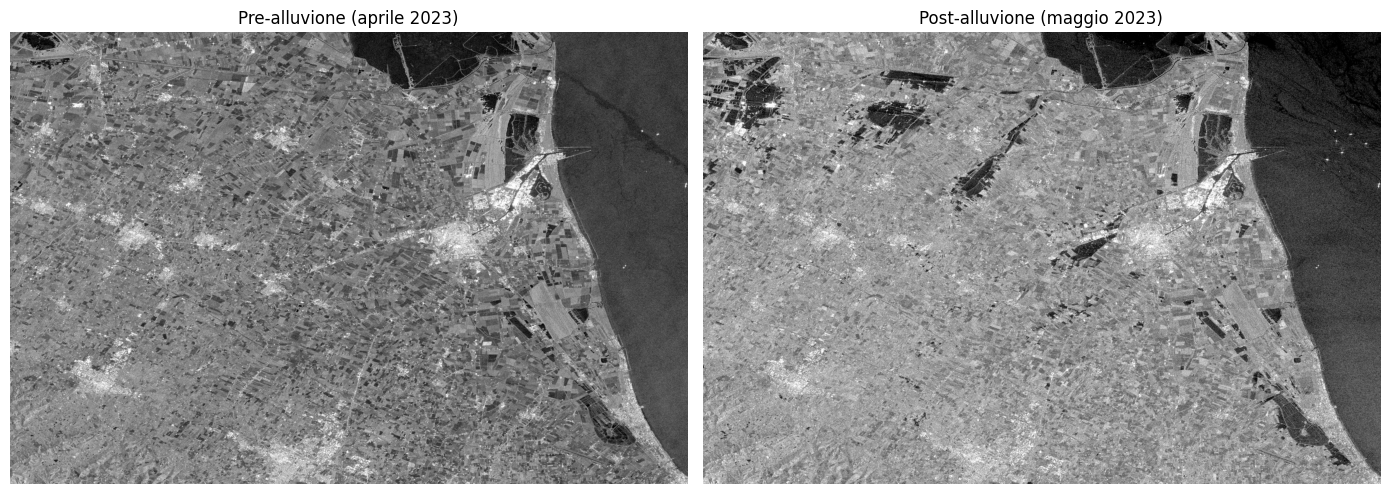

Post shape: (1487, 2228)


In [5]:
# Visualizzo il backscatter pre-alluvione grezzo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pre-alluvione
axes[0].imshow(pre_raw, cmap='gray', vmin=-25, vmax=0)
axes[0].set_title('Pre-alluvione (aprile 2023)')
axes[0].axis('off')

# Leggo e visualizzo anche il post
with rasterio.open(POST_PATH) as src:
    post_raw = src.read(1)

axes[1].imshow(post_raw, cmap='gray', vmin=-25, vmax=0)
axes[1].set_title('Post-alluvione (maggio 2023)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Post shape:", post_raw.shape)

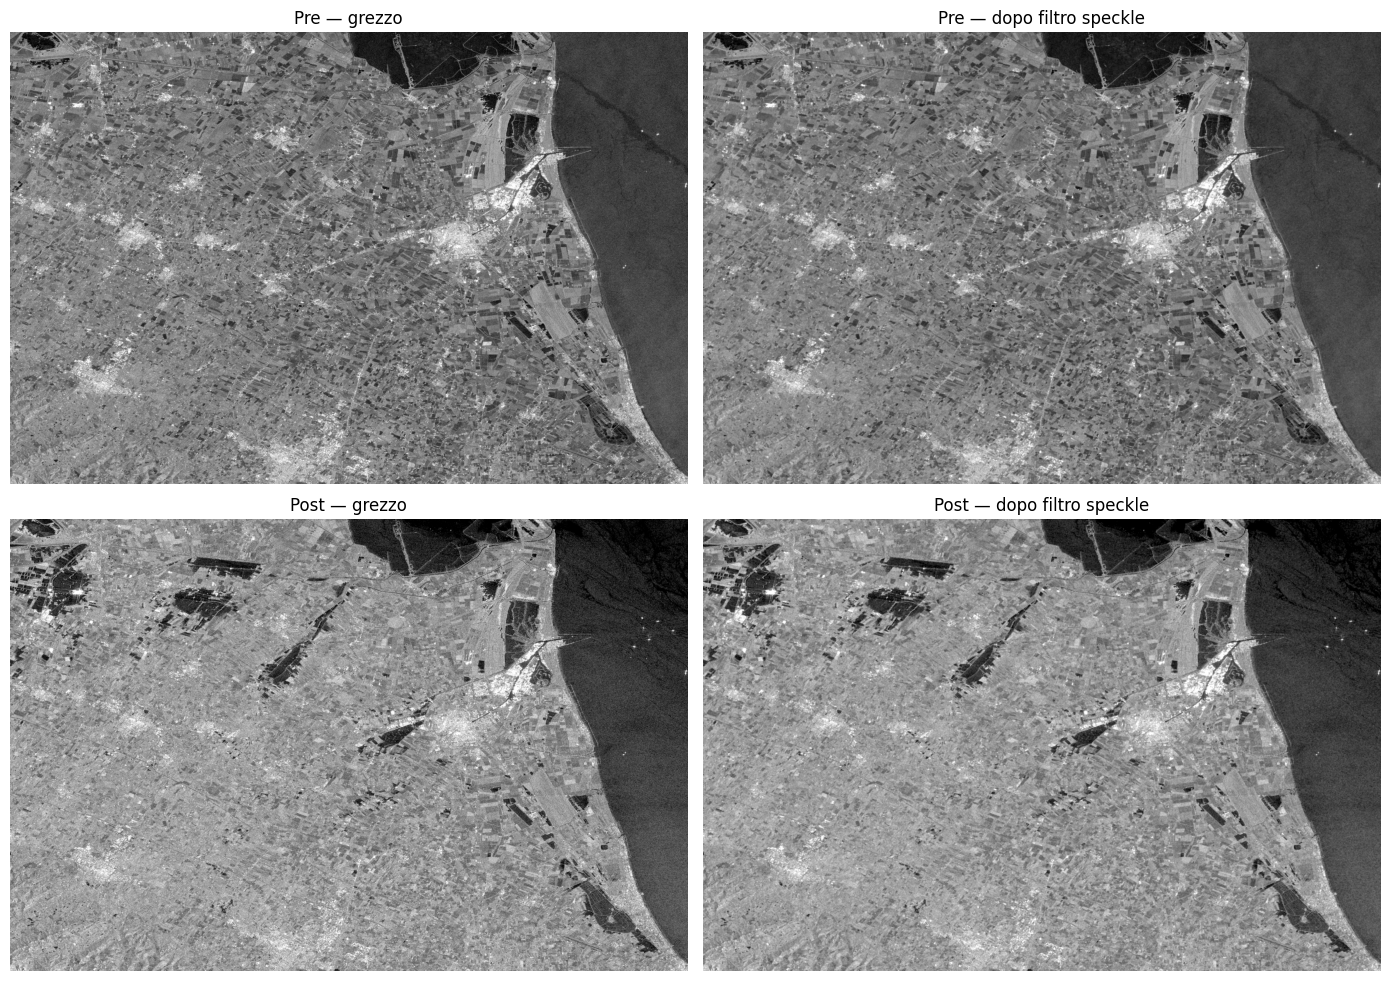

In [ ]:
from scipy.ndimage import uniform_filter, median_filter

# Filtro mediano 3x3 — finestra piccola per preservare i bordi
pre_filtered  = median_filter(pre_raw,  size=3) #scorre l'array pixel per pixel. Per ogni pixel prende una finestra 3x3 centrata su di esso, 9 valori, li ordina e prende quello centrale. Il risultato sostituisce il valore originale. La mediana è più robusta della media perché non viene influenzata da valori estremi isolati — perfetta per lo speckle che si manifesta proprio come pixel isolati anomali.
post_filtered = median_filter(post_raw, size=3)

# Confronto visivo prima/dopo filtro
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].imshow(pre_raw,      cmap='gray', vmin=-25, vmax=0)
axes[0,0].set_title('Pre — grezzo')
axes[0,0].axis('off')

axes[0,1].imshow(pre_filtered, cmap='gray', vmin=-25, vmax=0)
axes[0,1].set_title('Pre — dopo filtro speckle')
axes[0,1].axis('off')

axes[1,0].imshow(post_raw,      cmap='gray', vmin=-25, vmax=0)
axes[1,0].set_title('Post — grezzo')
axes[1,0].axis('off')

axes[1,1].imshow(post_filtered, cmap='gray', vmin=-25, vmax=0)
axes[1,1].set_title('Post — dopo filtro speckle')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Salvo i file filtrati mantenendo gli stessi metadati geografici
def salva_tiff(array, percorso, profile_originale):
    # Aggiorno il profile con il tipo dati corretto
    profile_out = profile_originale.copy()
    profile_out.update(dtype=rasterio.float32, count=1)
    
    with rasterio.open(percorso, 'w', **profile_out) as dst:
        dst.write(array.astype(np.float32), 1)
    
    print(f"Salvato: {percorso}")

# Percorsi output
pre_proc_path  = os.path.join(proc_dir, 's1_pre_filtered.tif')
post_proc_path = os.path.join(proc_dir, 's1_post_filtered.tif')

# Rileggo il profile dal file originale
with rasterio.open(PRE_PATH) as src:
    profile_pre = src.profile

with rasterio.open(POST_PATH) as src:
    profile_post = src.profile

salva_tiff(pre_filtered,  pre_proc_path,  profile_pre)
salva_tiff(post_filtered, post_proc_path, profile_post)

Salvato: c:\Users\frate\Desktop\FloodingMap_project\data\processed\s1_pre_filtered.tif
Salvato: c:\Users\frate\Desktop\FloodingMap_project\data\processed\s1_post_filtered.tif
